# Build a machine learning model - Gridsearch of Random Forest and XGBoost

**The purpose** find ways to generate more revenue for taxi cab drivers.  
  
**The goal** predict whether or not a customer is a generous tipper.  

### Imports and data loading

In [17]:
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn.metrics as metrics
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance

In [3]:
# Set to display all columns

pd.set_option('display.max_columns', None)

In [4]:
# Load dataset

df0 = pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')

nyc_preds_means = pd.read_csv('nyc_preds_means.csv')

# Basic look at Data

In [5]:
df0.head(10)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80
5,23345809,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36
6,37660487,2,05/03/2017 7:04:09 PM,05/03/2017 8:03:47 PM,1,12.83,1,N,79,241,1,47.5,1.0,0.5,9.86,0.0,0.3,59.16
7,69059411,2,08/15/2017 5:41:06 PM,08/15/2017 6:03:05 PM,1,2.98,1,N,237,114,1,16.0,1.0,0.5,1.78,0.0,0.3,19.58
8,8433159,2,02/04/2017 4:17:07 PM,02/04/2017 4:29:14 PM,1,1.20,1,N,234,249,2,9.0,0.0,0.5,0.00,0.0,0.3,9.80
9,95294817,1,11/10/2017 3:20:29 PM,11/10/2017 3:40:55 PM,1,1.60,1,N,239,237,1,13.0,0.0,0.5,2.75,0.0,0.3,16.55


In [6]:
nyc_preds_means.head(10)

,mean_duration,mean_distance,predicted_fare
0,22.847222,3.521667,16.434245
1,24.470370,3.108889,16.052218
2,7.250000,0.881429,7.053706
3,30.250000,3.700000,18.731650
4,14.616667,4.435000,15.845642
5,11.855376,2.052258,10.441351
6,59.633333,12.830000,45.374542
7,26.437500,4.022500,18.555128
8,7.873457,1.019259,7.151511
9,10.541111,1.580000,9.122755


In [7]:
# Merge the two datasets

df0 = df0.merge(nyc_preds_means, left_index=True, right_index=True)

df0.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,22.847222,3.521667,16.434245
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,24.470370,3.108889,16.052218
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7.250000,0.881429,7.053706
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.250000,3.700000,18.731650
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80,14.616667,4.435000,15.845642


In [8]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

### Some feature engineering

In [9]:
# Isolate only customers who paid by credit card

df1 = df0[df0['payment_type'] == 1]

#### `tip_percentage`

In [11]:
# Create tip percentage column

df1['tip_percentage'] = round((df1['tip_amount']/(df1['total_amount'] - df1['tip_amount'])), 3)
df1.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare,tip_percentage
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,22.847222,3.521667,16.434245,0.200
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,24.470370,3.108889,16.052218,0.238
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7.250000,0.881429,7.053706,0.199
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.250000,3.700000,18.731650,0.300
5,23345809,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36,11.855376,2.052258,10.441351,0.200


#### `generous`
Binary column:
* **1** correspond to a tip_percentage greater than 20%
* **0** correspond to a tip_percentage below 20%

In [16]:
# Create 'generous' col (target)
df1['generous'] = 0
df1.loc[df1['tip_percentage'] >= 0.2, 'generous'] = 1
df1.sample(15)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare,tip_percentage,generous
474,105890984,2,12/14/2017 10:22:24 AM,12/14/2017 10:29:17 AM,1,0.70,1,N,170,164,1,6.0,0.0,0.5,1.00,0.00,0.3,7.80,9.055556,0.748095,6.939496,0.147,0
21329,43550932,1,05/15/2017 3:39:24 PM,05/15/2017 4:20:11 PM,2,6.50,1,N,162,194,1,27.5,0.0,0.5,6.80,5.76,0.3,40.86,40.783333,6.500000,27.385645,0.200,1
10216,99390193,1,11/23/2017 2:28:08 PM,11/23/2017 2:37:30 PM,1,1.70,1,N,161,137,1,8.5,0.0,0.5,1.85,0.00,0.3,11.15,12.179630,1.542222,9.503579,0.199,0
18193,19858031,2,03/09/2017 12:08:39 PM,03/09/2017 12:20:25 PM,1,1.16,1,N,162,230,1,8.5,0.0,0.5,1.86,0.00,0.3,11.16,14.518137,0.924118,8.811728,0.200,1
17967,65556778,2,08/02/2017 8:52:10 PM,08/02/2017 9:12:26 PM,2,6.42,1,N,170,66,1,21.5,0.5,0.5,1.00,0.00,0.3,23.80,20.266667,6.420000,21.404067,0.044,0
19191,107094063,1,12/17/2017 5:02:22 PM,12/17/2017 6:00:54 PM,1,18.30,2,N,132,262,1,52.0,0.0,0.5,11.70,5.76,0.3,70.26,49.931250,19.165000,52.000000,0.200,1
3829,14119227,1,02/22/2017 12:12:35 PM,02/22/2017 12:25:42 PM,1,1.40,1,N,162,234,1,10.0,0.0,0.5,2.70,0.00,0.3,13.50,11.307619,1.478857,9.134329,0.250,1
815,94870757,2,11/09/2017 11:28:33 AM,11/09/2017 12:02:34 PM,2,1.49,1,N,229,48,1,19.5,0.0,0.5,3.00,0.00,0.3,23.30,22.311905,1.415714,11.986739,0.148,0
15761,88390174,2,10/20/2017 9:07:32 AM,10/20/2017 9:16:11 AM,1,0.85,1,N,170,162,1,7.0,0.0,0.5,1.56,0.00,0.3,9.36,7.914062,0.990938,7.347697,0.200,1
22252,55310570,2,06/05/2017 6:19:10 PM,06/05/2017 6:28:13 PM,3,0.64,1,N,161,233,1,7.0,1.0,0.5,1.00,0.00,0.3,9.80,8.418519,0.952222,7.458751,0.114,0


#### `Day`

In [19]:
# pickup and dropoff cols to datetime
df1['tpep_pickup_datetime'] = pd.to_datetime(df1['tpep_pickup_datetime'])
df1['tpep_dropoff_datetime'] = pd.to_datetime(df1['tpep_dropoff_datetime'])

# check
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15265 entries, 0 to 22698
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             15265 non-null  int64         
 1   VendorID               15265 non-null  int64         
 2   tpep_pickup_datetime   15265 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  15265 non-null  datetime64[ns]
 4   passenger_count        15265 non-null  int64         
 5   trip_distance          15265 non-null  float64       
 6   RatecodeID             15265 non-null  int64         
 7   store_and_fwd_flag     15265 non-null  object        
 8   PULocationID           15265 non-null  int64         
 9   DOLocationID           15265 non-null  int64         
 10  payment_type           15265 non-null  int64         
 11  fare_amount            15265 non-null  float64       
 12  extra                  15265 non-null  float64       
 13  mta_ta

In [20]:
# Day column

df1['day'] = df1['tpep_pickup_datetime'].dt.day
df1.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare,tip_percentage,generous,day
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,22.847222,3.521667,16.434245,0.200,1,25
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,24.470370,3.108889,16.052218,0.238,1,11
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7.250000,0.881429,7.053706,0.199,0,15
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.250000,3.700000,18.731650,0.300,1,7
5,23345809,2,2017-03-25 20:34:11,2017-03-25 20:42:11,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36,11.855376,2.052258,10.441351,0.200,1,25


#### `am_rush` - `daytime` - `pm_rush` - `nighttime`

Four binary column: 

`am_rush`: 
* **1** if the ride is between 6 and 10 am
* **0** instead
  
`daytime`: 
* **1** if the ride is between 10 am and 16 pm
* **0** instead
  
`pm_rush`:
* **1** if the ride is between 16 and 20 pm
* **0** instead

`nighttime`
* **1** if the ride is between 20 pm and 6 am
* **0** instead


In [24]:
# 'am_rush'
df1['am_rush'] = 0
df1.loc[(df1['tpep_pickup_datetime'].dt.hour >= 6) & (df1['tpep_pickup_datetime'].dt.hour < 10), 'am_rush'] = 1

# 'daytime'
df1['daytime'] = 0
df1.loc[(df1['tpep_pickup_datetime'].dt.hour >= 10) & (df1['tpep_pickup_datetime'].dt.hour < 16), 'daytime'] = 1

# 'pm_rush'
df1['pm_rush'] = 0
df1.loc[(df1['tpep_pickup_datetime'].dt.hour >= 16) & (df1['tpep_pickup_datetime'].dt.hour < 20), 'pm_rush'] = 1


# 'nighttime'
df1['nighttime'] = 0
df1.loc[(df1['tpep_pickup_datetime'].dt.hour >= 20) & (df1['tpep_pickup_datetime'].dt.hour < 6), 'nighttime'] = 1



In [25]:
# Check
df1.sample(15)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare,tip_percentage,generous,day,am_rush,daytime,pm_rush,nighttime
20506,12545003,2,2017-02-17 08:44:22,2017-02-17 08:51:04,2,1.01,1,N,162,141,1,6.5,0.0,0.5,1.00,0.00,0.3,8.30,8.131481,1.082593,7.615074,0.137,0,17,1,0,0,0
7993,112717348,1,2017-01-19 08:53:10,2017-01-19 09:12:06,1,2.10,1,N,238,230,1,13.0,0.0,0.5,3.45,0.00,0.3,17.25,14.716667,2.418000,12.199113,0.250,1,19,1,0,0,0
13904,107451537,2,2017-12-18 21:18:50,2017-12-18 21:38:15,6,1.96,1,N,142,233,1,13.0,0.5,0.5,2.14,0.00,0.3,16.44,21.898148,2.294444,13.720891,0.150,0,18,0,0,0,0
12843,101502438,2,2017-12-01 08:17:55,2017-12-01 08:55:17,1,8.87,1,N,138,238,1,28.5,0.0,0.5,7.01,5.76,0.3,42.07,28.107407,9.202222,29.356977,0.200,1,1,1,0,0,0
7278,62036886,1,2017-07-21 14:24:29,2017-07-21 14:31:17,1,0.40,1,N,186,170,1,6.0,0.0,0.5,1.00,0.00,0.3,7.80,9.002381,1.025476,7.587691,0.147,0,21,0,1,0,0
10664,50285657,2,2017-06-14 13:33:24,2017-06-14 13:46:40,5,1.17,1,N,170,161,1,9.5,0.0,0.5,1.00,0.00,0.3,11.30,8.720139,0.917708,7.280313,0.097,0,14,0,1,0,0
1560,4639380,1,2017-01-24 20:35:32,2017-01-24 21:04:32,4,4.90,1,N,211,163,1,20.5,0.5,0.5,4.35,0.00,0.3,26.15,21.950000,4.200000,17.599730,0.200,1,24,0,0,0,0
7481,47472741,1,2017-06-02 08:29:11,2017-06-02 08:49:00,1,2.60,1,N,239,75,1,13.5,0.0,0.5,2.85,0.00,0.3,17.15,13.346296,2.262222,11.506682,0.199,0,2,1,0,0,0
17340,55357067,2,2017-06-05 21:52:44,2017-06-05 22:08:45,1,3.07,1,N,161,262,1,13.0,0.5,0.5,2.86,0.00,0.3,17.16,15.790000,2.904000,13.117000,0.200,1,5,0,0,0,0
5288,17014358,2,2017-03-01 21:28:53,2017-03-01 21:33:59,1,0.46,1,N,231,13,1,5.0,0.5,0.5,1.00,0.00,0.3,7.30,6.362281,0.926842,6.546320,0.159,0,1,0,0,0,0


#### `month`

In [28]:
df1['month'] = df1['tpep_pickup_datetime'].dt.month

#### Drop usless or reduntant columns

In [32]:
# Drop columns
drop_cols = ['Unnamed: 0', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
             'payment_type', 'trip_distance', 'store_and_fwd_flag', 'payment_type',
             'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
             'improvement_surcharge', 'total_amount', 'tip_percentage']

df1 = df1.drop(drop_cols, axis=1)
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15265 entries, 0 to 22698
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         15265 non-null  int64  
 1   passenger_count  15265 non-null  int64  
 2   RatecodeID       15265 non-null  int64  
 3   PULocationID     15265 non-null  int64  
 4   DOLocationID     15265 non-null  int64  
 5   mean_duration    15265 non-null  float64
 6   mean_distance    15265 non-null  float64
 7   predicted_fare   15265 non-null  float64
 8   generous         15265 non-null  int64  
 9   day              15265 non-null  int32  
 10  am_rush          15265 non-null  int64  
 11  daytime          15265 non-null  int64  
 12  pm_rush          15265 non-null  int64  
 13  nighttime        15265 non-null  int64  
 14  month            15265 non-null  int32  
dtypes: float64(3), int32(2), int64(10)
memory usage: 1.7 MB


#### Variable encoding

In [33]:
# Convert to string the columns that have to be encoded

cols_to_str = ['RatecodeID', 'PULocationID', 'DOLocationID', 'VendorID']
for col in cols_to_str:
    df1[col] = df1[col].astype('str')

In [36]:
# Dummies the categorical variable

df2 = pd.get_dummies(df1, drop_first = True)

df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15265 entries, 0 to 22698
Columns: 332 entries, passenger_count to DOLocationID_97
dtypes: bool(321), float64(3), int32(2), int64(6)
memory usage: 6.0 MB


##### Check value balance

In [39]:
# Get class balance of 'generous' col
df2['generous'].value_counts(normalize = True)

generous
1    0.526368
0    0.473632
Name: proportion, dtype: float64

To balance between the client and the cab driver f1 score is the best to balance precision and recall

### Build the model

In [40]:
# Isolate target and feature
y = df2['generous']
x = df2.drop(columns = 'generous')

# Split train and test data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, random_state = 42)

In [48]:
# Random Forest
rf = RandomForestClassifier(random_state = 42)

# hyperparameter
cv_param = {'max_depth' : [None],
           'max_features' : [1.0],
           'max_samples' : [0.7],
           'min_samples_leaf' : [1],
           'min_samples_split' : [2],
           'n_estimators' : [300]}

# scoring metrics
scoring = ['precision', 'recall', 'accuracy', 'f1']

# GridSearchCV
rf_cv = GridSearchCV(rf, cv_param, scoring = scoring, cv = 4, refit = 'f1')

In [49]:
%%time

# fit
rf_cv.fit(x_train, y_train)

CPU times: user 4min 13s, sys: 355 ms, total: 4min 14s
Wall time: 4min 14s


GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None], 'max_features': [1.0],
                         'max_samples': [0.7], 'min_samples_leaf': [1],
                         'min_samples_split': [2], 'n_estimators': [300]},
             refit='f1', scoring=['precision', 'recall', 'accuracy', 'f1'])

In [50]:
# Best score of f1
rf_cv.best_score_

0.7189920802777848

In [51]:
# Best hyperparameters
rf_cv.best_params_

{'max_depth': None,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [52]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
    model_name (string): what you want the model to be called in the output table
    model_object: a fit GridSearchCV object
    metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                 'recall': 'mean_test_recall',
                 'f1': 'mean_test_f1',
                 'accuracy': 'mean_test_accuracy',
                 }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract Accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                        'precision': [precision],
                        'recall': [recall],
                        'F1': [f1],
                        'accuracy': [accuracy],
                        },
                       )

    return table

In [54]:
# dataframe of the best score
table = make_results('Random Forest CV', rf_cv, 'f1')
table

,model,precision,recall,F1,accuracy
0,Random Forest CV,0.675741,0.768357,0.718992,0.683999


In [55]:
# Test data
y_pred = rf_cv.best_estimator_.predict(x_test)

In [58]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
    model_name (string): Your choice: how the model will be named in the output table
    preds: numpy array of test predictions
    y_test_data: numpy array of y_test data

    Out:
    table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = metrics.accuracy_score(y_test_data, preds)
    precision = metrics.precision_score(y_test_data, preds)
    recall = metrics.recall_score(y_test_data, preds)
    f1 = metrics.f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                        'precision': [precision],
                        'recall': [recall],
                        'F1': [f1],
                        'accuracy': [accuracy]
                        })

    return table

In [59]:
 # Score on the test data and compare
table2 = get_test_scores('Random Forest test', y_pred, y_test)
results = pd.concat([table, table2], axis=0)
results

,model,precision,recall,F1,accuracy
0,Random Forest CV,0.675741,0.768357,0.718992,0.683999
0,Random Forest test,0.671983,0.786559,0.724771,0.685555


## **XGBoost**

In [64]:
# XGBoost classifier
xgb = XGBClassifier(objective = 'binary:logistic', random_state = 0)

# Hyperparameters
cv_params = {'learning_rate': [0.1],
             'max_depth': [8],
             'min_child_weight': [2],
             'n_estimators': [500]
             }

# Scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1']

# GridSearchCV 
xgb_cv = GridSearchCV(xgb, cv_params, scoring = scoring, cv = 4, refit = 'f1')

In [65]:
%%time

# Fit
xgb_cv.fit(x_train, y_train)

CPU times: user 24.1 s, sys: 87.7 ms, total: 24.1 s
Wall time: 12.6 s


GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=0, ...),
             param_grid={'learning_rate': [0.1], 'max_depth': [8],
                         'min_child_weight': [2], 'n_estimators': [500]},
             refit='f1', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [66]:
# Best score of F1

xgb_cv.best_score_

0.6931193735401817

In [67]:
# Best hyperparameters

xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 8,
 'min_child_weight': 2,
 'n_estimators': 500}

In [68]:
# Dataframe of best score of XGBoost

table3 = make_results('XGBoost CV', xgb_cv, 'f1')
table3

,model,precision,recall,F1,accuracy
0,XGBoost CV,0.669652,0.718419,0.693119,0.665247


In [69]:
# Scores on test data

y_predxgb = xgb_cv.best_estimator_.predict(x_test)

In [71]:
table4 = get_test_scores('XGB test', y_predxgb, y_test)
results2 = pd.concat([table3, table4], axis=0)
results2

,model,precision,recall,F1,accuracy
0,XGBoost CV,0.669652,0.718419,0.693119,0.665247
0,XGB test,0.666857,0.727442,0.695833,0.665247


##### Compare all scores

In [74]:
total_result = pd.concat([results, results2], axis = 0)
total_result

,model,precision,recall,F1,accuracy
0,Random Forest CV,0.675741,0.768357,0.718992,0.683999
0,Random Forest test,0.671983,0.786559,0.724771,0.685555
0,XGBoost CV,0.669652,0.718419,0.693119,0.665247
0,XGB test,0.666857,0.727442,0.695833,0.665247


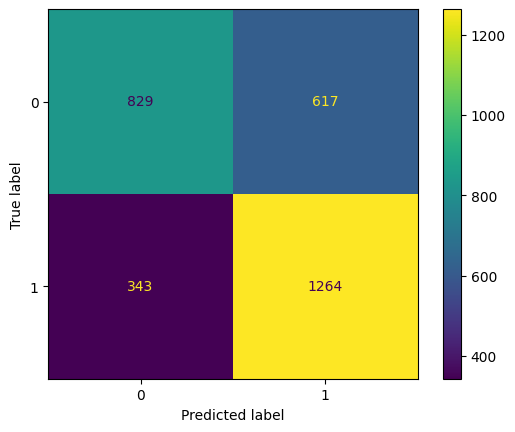

In [76]:
# Confusion matrix

cm = metrics.confusion_matrix(y_test, y_pred, labels = rf_cv.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = rf_cv.classes_)

disp.plot()

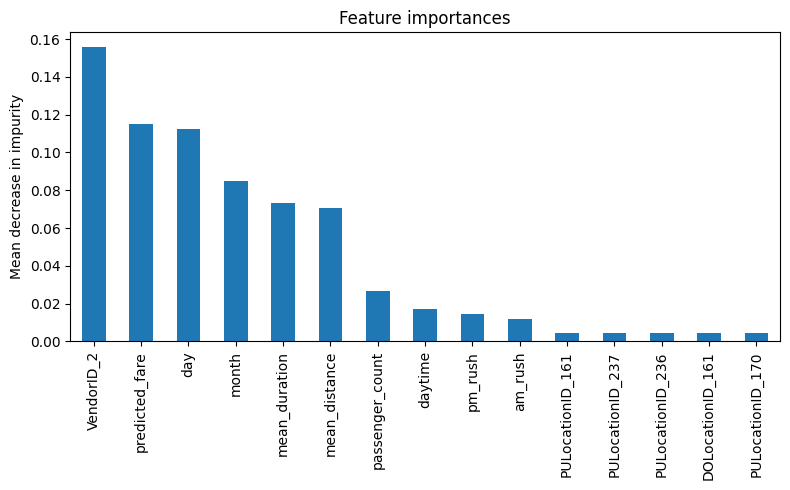

In [77]:
# Importance features
importance = rf_cv.best_estimator_.feature_importances_ # importance
rf_importance = pd.Series(importance, index=x_test.columns) # Series
rf_importance = rf_importance.sort_values(ascending=False)[:15] # Sort in descending order

# Visualization
fig, ax = plt.subplots(figsize=(8,5))
rf_importance.plot.bar(ax=ax)
ax.set_title('Feature importances')
ax.set_ylabel('Mean decrease in impurity')
fig.tight_layout();